In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nAttrition Value Counts:\n", df['Attrition'].value_counts())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape: (1470, 35)

Attrition Value Counts:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64

Data Types:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
Relatio

In [ ]:
#cleaning data
#1. Drop useless columns (same value in every row)
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'], inplace=True)
print("Dropped 3 useless columns")
print("New Shape:", df.shape)  # Should be (1470, 32)
# 2. Convert Attrition to numeric (Yes=1, No=0)
# We need this for correlation analysis and model later
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("\nAttrition converted to numeric")
# 3. Convert OverTime to numeric (Yes=1, No=0)
df['OverTime_Num'] = df['OverTime'].map({'Yes': 1, 'No': 0})
print("OverTime converted to numeric")
# 4. Check satisfaction columns — should be 1 to 4 only
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance']
print("\nSatisfaction Column Ranges:")
for col in sat_cols:
    print(f"{col} → Min: {df[col].min()}, Max: {df[col].max()}")

# 5. Check age and income for outliers
print("\nAge        → Min:", df['Age'].min(), "Max:", df['Age'].max())
print("MonthlyIncome → Min:", df['MonthlyIncome'].min(),
      "Max:", df['MonthlyIncome'].max())

# 6. Check YearsAtCompany for negatives
print("YearsAtCompany → Min:", df['YearsAtCompany'].min(),
      "Max:", df['YearsAtCompany'].max())

Dropped 3 useless columns
New Shape: (1470, 32)

Attrition converted to numeric
OverTime converted to numeric

Satisfaction Column Ranges:
JobSatisfaction → Min: 1, Max: 4
EnvironmentSatisfaction → Min: 1, Max: 4
RelationshipSatisfaction → Min: 1, Max: 4
WorkLifeBalance → Min: 1, Max: 4

Age        → Min: 18 Max: 60
MonthlyIncome → Min: 1009 Max: 19999
YearsAtCompany → Min: 0 Max: 40


In [ ]:
# Save cleaned dataframe for use throughout project
df.to_csv('HR_Attrition_Cleaned.csv', index=False)
print("Cleaned file saved successfully")
print("Shape:", df.shape)

Cleaned file saved successfully
Shape: (1470, 34)


In [ ]:
# Reload cleaned data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
# If disconnected, re-upload file first
# Otherwise just run:
df = pd.read_csv('HR_Attrition_Cleaned.csv')
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime_Num'] = df['OverTime'].map({'Yes': 1, 'No': 0})

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (1470, 34)


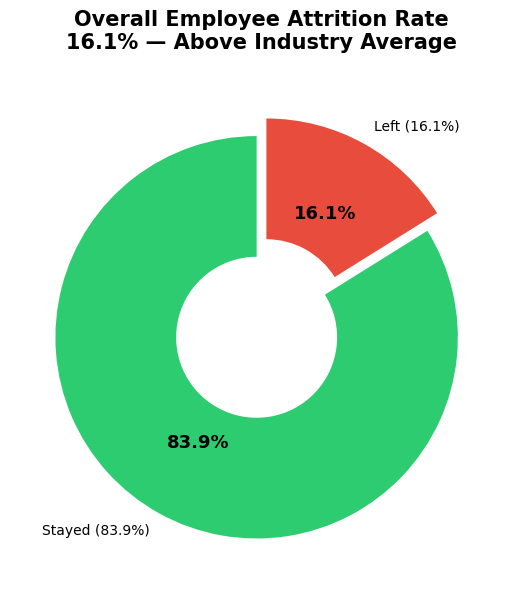

Chart 1 saved


In [ ]:
# Chart 1 : Attrition Distribution
fig, ax = plt.subplots(figsize=(8, 6))

attrition_counts = df['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax.pie(
    attrition_counts,
    labels=['Stayed (83.9%)', 'Left (16.1%)'],
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)

for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

ax.set_title('Overall Employee Attrition Rate\n16.1% — Above Industry Average',
             fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart1_attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

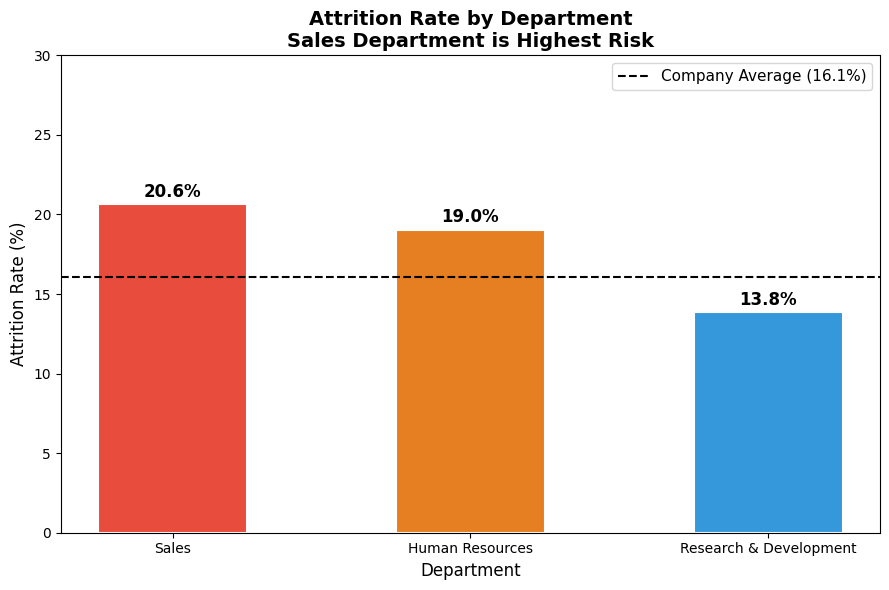

Chart 2 saved


In [ ]:
# Chart 2 — Department Attrition Rate
dept_data = df.groupby('Department')['Attrition_Num'].mean() * 100
dept_data = dept_data.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(dept_data.index, dept_data.values,
              color=['#e74c3c', '#e67e22', '#3498db'],
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, dept_data.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center',
            fontweight='bold', fontsize=12)

ax.axhline(y=16.1, color='black', linestyle='--',
           linewidth=1.5, label='Company Average (16.1%)')

ax.set_title('Attrition Rate by Department\nSales Department is Highest Risk',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_xlabel('Department', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig('chart2_department_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

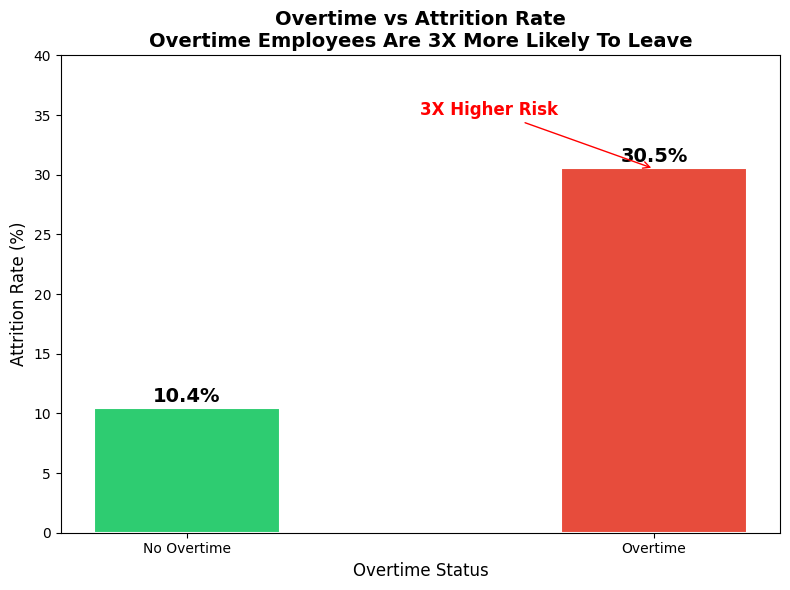

Chart 3 saved


In [ ]:
# Chart 3 — Overtime vs Attrition (Most Important Finding)
overtime_data = df.groupby('OverTime')['Attrition_Num'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(['No Overtime', 'Overtime'],
              overtime_data.values,
              color=['#2ecc71', '#e74c3c'],
              edgecolor='white', linewidth=1.5,
              width=0.4)

for bar, val in zip(bars, overtime_data.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center',
            fontweight='bold', fontsize=14)

ax.set_title('Overtime vs Attrition Rate\nOvertime Employees Are 3X More Likely To Leave',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_xlabel('Overtime Status', fontsize=12)
ax.set_ylim(0, 40)

# Add annotation arrow
ax.annotate('3X Higher Risk',
            xy=(1, 30.5), xytext=(0.5, 35),
            fontsize=12, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('chart3_overtime_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

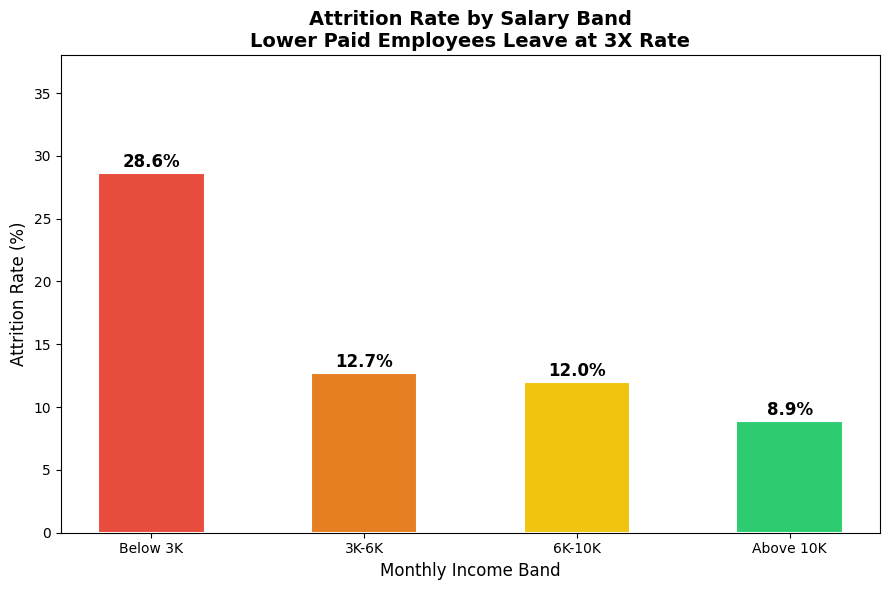

Chart 4 saved


In [ ]:
# Chart 4 — Salary Band vs Attrition
df['SalaryBand'] = pd.cut(df['MonthlyIncome'],
                           bins=[0, 3000, 6000, 10000, 20000],
                           labels=['Below 3K', '3K-6K', '6K-10K', 'Above 10K'])

salary_data = df.groupby('SalaryBand')['Attrition_Num'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = ax.bar(salary_data.index, salary_data.values,
              color=colors, edgecolor='white',
              linewidth=1.5, width=0.5)

for bar, val in zip(bars, salary_data.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Attrition Rate by Salary Band\nLower Paid Employees Leave at 3X Rate',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_xlabel('Monthly Income Band', fontsize=12)
ax.set_ylim(0, 38)

plt.tight_layout()
plt.savefig('chart4_salary_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

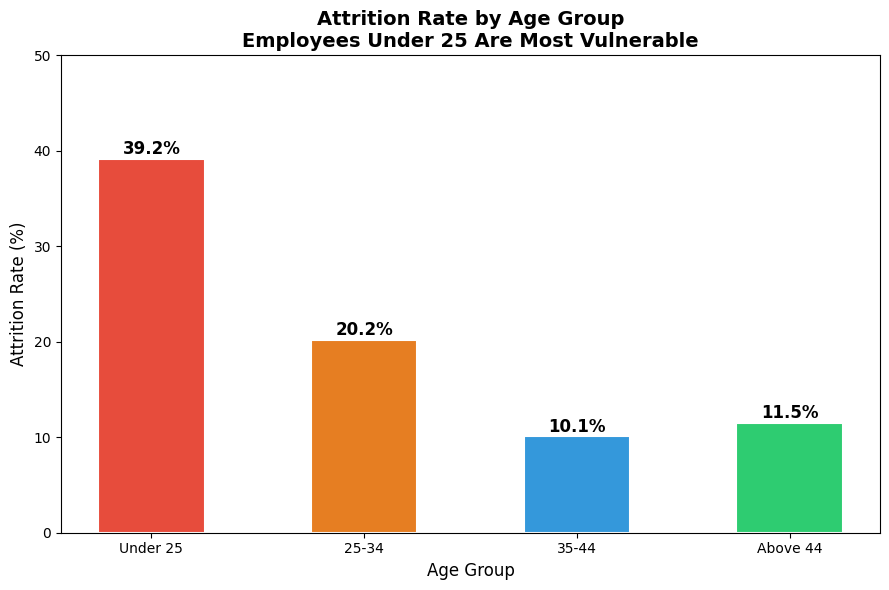

Chart 5 saved


In [ ]:
# Chart 5 — Age Group vs Attrition
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[17, 24, 34, 44, 60],
                         labels=['Under 25', '25-34', '35-44', 'Above 44'])

age_data = df.groupby('AgeGroup')['Attrition_Num'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
bars = ax.bar(age_data.index, age_data.values,
              color=colors, edgecolor='white',
              linewidth=1.5, width=0.5)

for bar, val in zip(bars, age_data.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Attrition Rate by Age Group\nEmployees Under 25 Are Most Vulnerable',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylim(0, 50)

plt.tight_layout()
plt.savefig('chart5_age_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

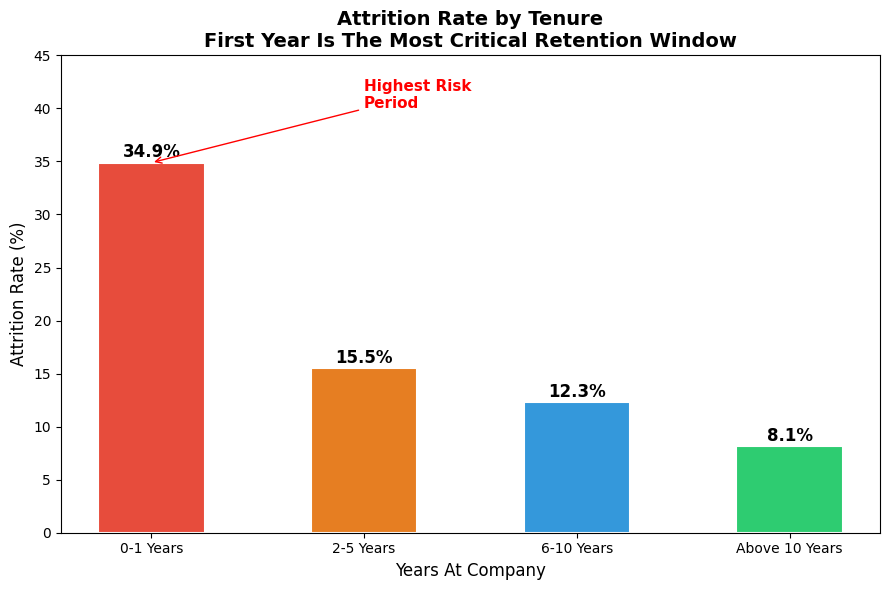

Chart 6 saved


In [ ]:
# Chart 6 — Tenure vs Attrition (First Year Crisis)
df['TenureBand'] = pd.cut(df['YearsAtCompany'],
                            bins=[-1, 1, 5, 10, 40],
                            labels=['0-1 Years', '2-5 Years',
                                    '6-10 Years', 'Above 10 Years'])

tenure_data = df.groupby('TenureBand')['Attrition_Num'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
bars = ax.bar(tenure_data.index, tenure_data.values,
              color=colors, edgecolor='white',
              linewidth=1.5, width=0.5)

for bar, val in zip(bars, tenure_data.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Attrition Rate by Tenure\nFirst Year Is The Most Critical Retention Window',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_xlabel('Years At Company', fontsize=12)
ax.set_ylim(0, 45)

ax.annotate('Highest Risk\nPeriod',
            xy=(0, 34.88), xytext=(1, 40),
            fontsize=11, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('chart6_tenure_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved")

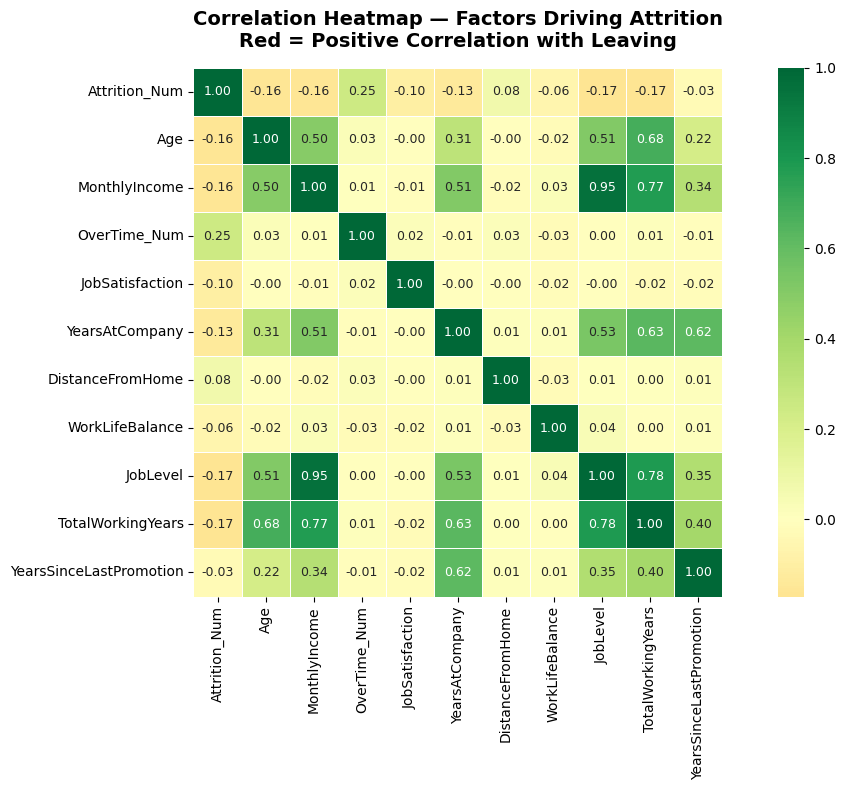

Chart 7 saved


In [ ]:
# Chart 7 — Correlation Heatmap (What drives attrition most)
numeric_cols = ['Attrition_Num', 'Age', 'MonthlyIncome',
                'OverTime_Num', 'JobSatisfaction',
                'YearsAtCompany', 'DistanceFromHome',
                'WorkLifeBalance', 'JobLevel',
                'TotalWorkingYears', 'YearsSinceLastPromotion']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Heatmap — Factors Driving Attrition\nRed = Positive Correlation with Leaving',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved")

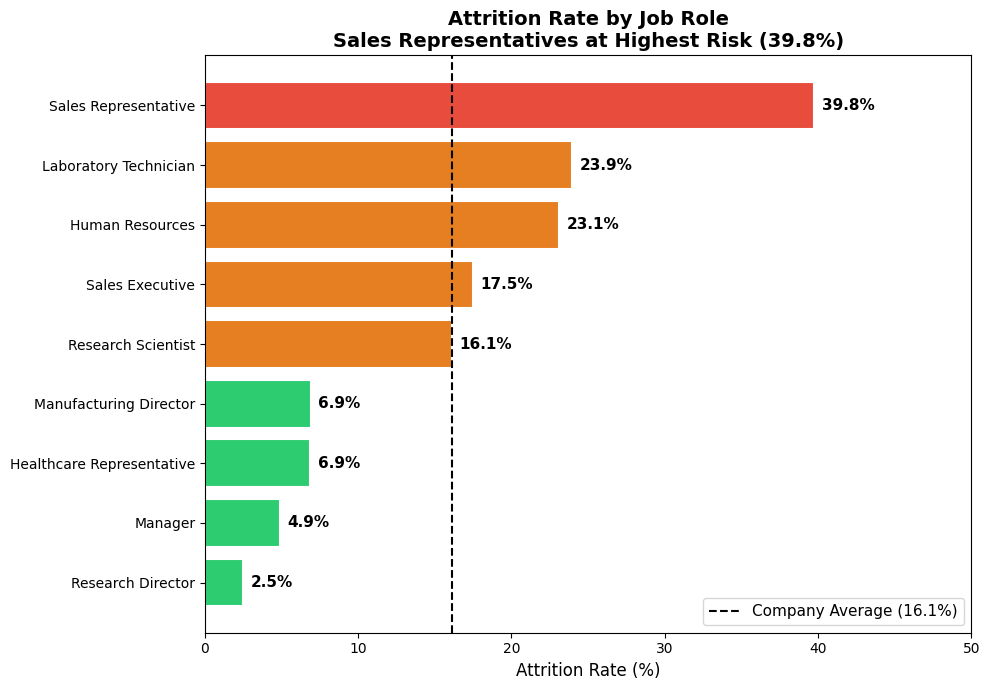

Chart 8 saved


In [ ]:
# Chart 8 — Job Role Attrition Rate
role_data = df.groupby('JobRole')['Attrition_Num'].mean() * 100
role_data = role_data.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#2ecc71' if x < 15 else '#e67e22'
          if x < 25 else '#e74c3c' for x in role_data.values]

bars = ax.barh(role_data.index, role_data.values,
               color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, role_data.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center',
            fontweight='bold', fontsize=11)

ax.axvline(x=16.1, color='black', linestyle='--',
           linewidth=1.5, label='Company Average (16.1%)')

ax.set_title('Attrition Rate by Job Role\nSales Representatives at Highest Risk (39.8%)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Attrition Rate (%)', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(0, 50)

plt.tight_layout()
plt.savefig('chart8_jobrole_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved")

In [ ]:
# Chi-Square Test — Overtime vs Attrition
from scipy import stats

# Create contingency table
contingency_table = pd.crosstab(df['OverTime'], df['Attrition'])
print("Contingency Table:")
print(contingency_table)

# Run chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.6f}")
print(f"Degrees of Freedom   : {dof}")

print("\n--- INTERPRETATION ---")
if p_value < 0.05:
    print("P-value < 0.05")
    print("RESULT: Overtime and Attrition are SIGNIFICANTLY related")
    print("This is NOT random — overtime genuinely drives attrition")
else:
    print("P-value > 0.05")
    print("RESULT: No significant relationship found")

Contingency Table:
Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127

Chi-Square Statistic : 87.5643
P-Value              : 0.000000
Degrees of Freedom   : 1

--- INTERPRETATION ---
P-value < 0.05
RESULT: Overtime and Attrition are SIGNIFICANTLY related
This is NOT random — overtime genuinely drives attrition


In [ ]:
# ──────────────────────────────────────────
# STEP 5 : LOGISTIC REGRESSION MODEL
# ──────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

# Step 5a — Prepare features
# Select most relevant columns based on our analysis
features = ['Age', 'MonthlyIncome', 'OverTime_Num',
            'JobSatisfaction', 'YearsAtCompany',
            'DistanceFromHome', 'WorkLifeBalance',
            'JobLevel', 'TotalWorkingYears',
            'YearsSinceLastPromotion', 'Attrition_Num']

model_df = df[features].copy()

# Step 5b — Define X and y
X = model_df.drop('Attrition_Num', axis=1)
y = model_df['Attrition_Num']

print("Features used:", X.columns.tolist())
print("Target distribution:\n", y.value_counts())

# Step 5c — Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size : {X_train.shape[0]}")
print(f"Testing set size  : {X_test.shape[0]}")

# Step 5d — Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5e — Train model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Step 5f — Predictions
y_pred = model.predict(X_test_scaled)

# Step 5g — Results
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy : {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Left']))

Features used: ['Age', 'MonthlyIncome', 'OverTime_Num', 'JobSatisfaction', 'YearsAtCompany', 'DistanceFromHome', 'WorkLifeBalance', 'JobLevel', 'TotalWorkingYears', 'YearsSinceLastPromotion']
Target distribution:
 Attrition_Num
0    1233
1     237
Name: count, dtype: int64

Training set size : 1176
Testing set size  : 294

Model Accuracy : 85.37%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.98      0.92       247
        Left       0.67      0.17      0.27        47

    accuracy                           0.85       294
   macro avg       0.76      0.58      0.59       294
weighted avg       0.83      0.85      0.82       294



Model Accuracy : 70.75%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.94      0.70      0.80       247
        Left       0.32      0.77      0.46        47

    accuracy                           0.71       294
   macro avg       0.63      0.73      0.63       294
weighted avg       0.84      0.71      0.74       294



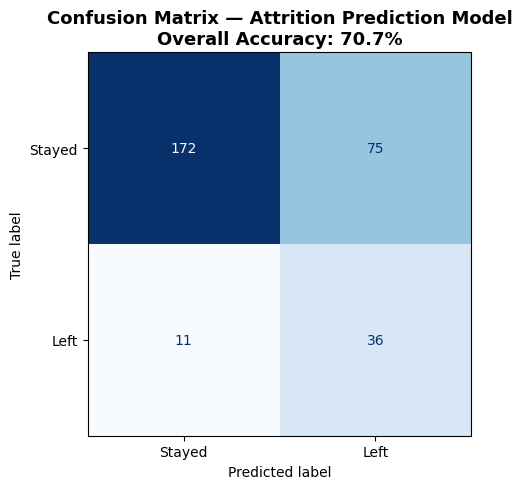

Chart 9 saved


In [ ]:
# Improved Model — Handle Class Imbalance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)

# Same features and split
X = model_df.drop('Attrition_Num', axis=1)
y = model_df['Attrition_Num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight='balanced' fixes imbalance problem
model = LogisticRegression(random_state=42,
                           max_iter=1000,
                           class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy : {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Left']))

# Confusion Matrix Chart
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Stayed', 'Left'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Attrition Prediction Model\n'
             f'Overall Accuracy: {accuracy*100:.1f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart9_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved")

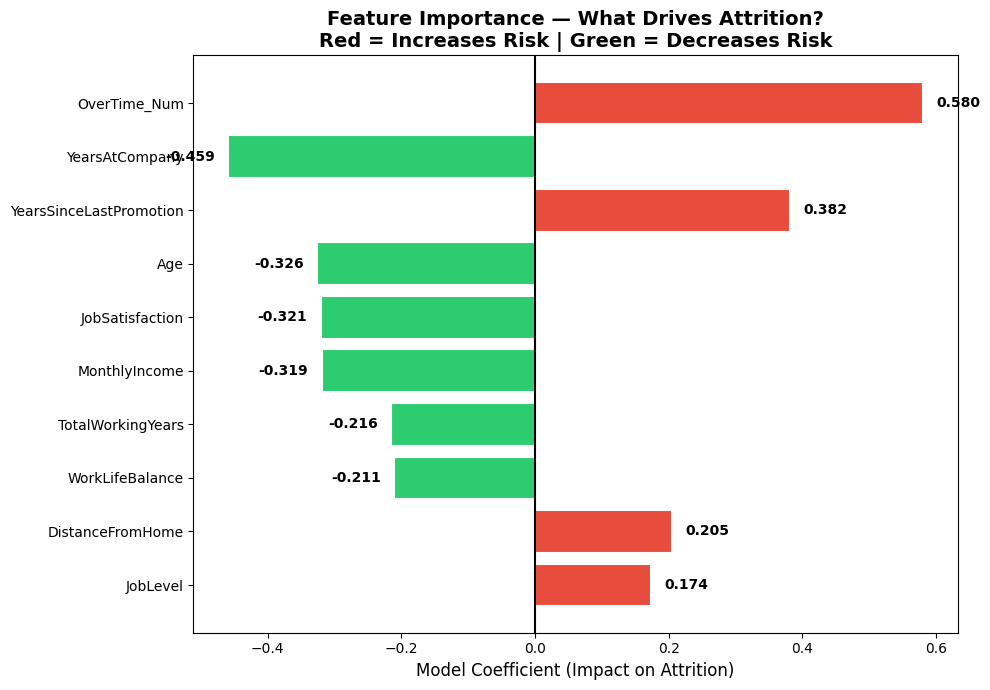

Chart 10 saved


In [ ]:
# Chart 10 — Feature Importance
import numpy as np

feature_names = X.columns.tolist()
coefficients = model.coef_[0]

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=True)

# Color — positive = increases attrition risk
#         negative = decreases attrition risk
colors = ['#e74c3c' if c > 0 else '#2ecc71'
          for c in importance_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(importance_df['Feature'],
               importance_df['Coefficient'],
               color=colors, edgecolor='white',
               linewidth=1.5)

ax.axvline(x=0, color='black', linewidth=1.5)

ax.set_title('Feature Importance — What Drives Attrition?\n'
             'Red = Increases Risk | Green = Decreases Risk',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Model Coefficient (Impact on Attrition)',
              fontsize=12)

# Add value labels
for bar, val in zip(bars, importance_df['Coefficient']):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            fontweight='bold', fontsize=10,
            ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.savefig('chart10_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved")

In [ ]:
# Download all charts
from google.colab import files
import os

charts = [f for f in os.listdir('/content/')
          if f.endswith('.png')]

print("Charts to download:")
for chart in sorted(charts):
    print(f"  {chart}")

print(f"\nTotal: {len(charts)} charts")

# Download each one
for chart in sorted(charts):
    files.download(chart)

print("All charts downloaded")

Charts to download:
  chart10_feature_importance.png
  chart1_attrition_distribution.png
  chart2_department_attrition.png
  chart3_overtime_attrition.png
  chart4_salary_attrition.png
  chart5_age_attrition.png
  chart6_tenure_attrition.png
  chart7_correlation_heatmap.png
  chart8_jobrole_attrition.png
  chart9_confusion_matrix.png

Total: 10 charts


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All charts downloaded
